<div class='alert alert-block alert-info"'>
<h1> Application to plant senescence genetic marker
identification :</h1>

<h4> Estimation and variable selection in an Mixed-effect models </h4>

In [27]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

### Model Specification

First, let's define the model with the abstract object AbstractMixedEffectsModel. We want to define the following logisitc models :

$$ \left\{\begin{array}{rll}
            Y_{i,j} &= m(t_{i,j}; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_{i,j}; \ksi_i) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_{i,j}}{\tau} \right)}$ 

In [28]:
# pylint: disable=C0116, W0221
import functools
from jax import jit
import parametrization_cookbook.jax as pc

from sdg4varselect.models import (
    AbstractMixedEffectsModel,
    AbstractHDModel,
    cov_simulation,
)


class HDLogisticMixedEffectsModel(AbstractMixedEffectsModel, AbstractHDModel):
    def __init__(self, N=1, J=1, P=1, **kwargs):
        AbstractMixedEffectsModel.__init__(
            self,
            N=N,
            J=J,
            me_name=["ksi"],
            **kwargs,
        )
        AbstractHDModel.__init__(self, P=P)

        self.init()

    @property
    def name(self):
        """return a str called name, based on the parameter of the model"""
        return f"HDLogisticMEM_N{self.N}_J{self.J}_P{self.P}"

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu=pc.RealPositive(scale=2000),
            ),
            psi1=pc.RealPositive(scale=100),
            psi2=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixSymPosDef(dim=1, scale=(100)),
            var_residual=pc.RealPositive(scale=100),
            beta=pc.Real(scale=10, shape=(self.P,)),
        )
        AbstractHDModel.init_dim(self)

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        ksi: jnp.ndarray,  # shape = (N,) [:,None]
        cov: jnp.ndarray,  # shape = (N,p)
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        psi1 = supremum
        ksi = midpoint
        psi2 = growth rate
        """
        phi = cov @ params.beta + ksi

        out = params.psi1 / (1 + jnp.exp(-(times - phi[:, None]) / params.psi2))
        assert out.shape == times.shape
        return out

    # ============================================================== #
    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_time,
            prngkey_mem,
            prngkey_cov,
        ) = jrd.split(prngkey, num=3)

        # === nlmem_simulation() === #
        time = 150 + jnp.arange(0, self.J - 1) * (3000 - 150) / (self.J - 1)
        time = jnp.repeat(time[None, :], self.N, axis=0)

        cov = cov_simulation(prngkey_cov, cov_min=-1, cov_max=1, shape=(self.N, self.P))

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time, cov=cov
        )

        return {"mem_obs_time": time, "cov": cov} | obs, sim


HDLogisticMEM = HDLogisticMixedEffectsModel

### Data Generation
Then we can generate a data set with $N=1000$ individuals and $J=20$ observation time per individuals

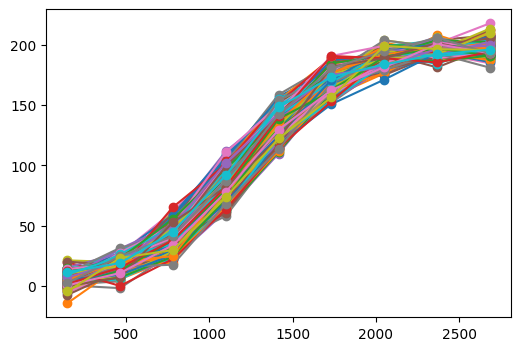

In [29]:
myModel = HDLogisticMixedEffectsModel(N=200, J=10, P=5)

p_star = myModel.new_params(
    mean_latent={"mu": 1200},
    psi1=200,
    psi2=300,
    cov_latent=jnp.diag(jnp.array([200])),
    var_residual=30,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)

myobs, mysim = myModel.sample(p_star, jrd.PRNGKey(0))

fig = sdgplt.figure(4, 6)
ax = fig.add_subplot(1, 1, 1)
_ = ax.plot(myobs["mem_obs_time"].T, myobs["Y"].T, "o-")

# Estimation example

Let's do an estimation of the parameter with the SGD-FIM algorithm

first we need to intiate the algorithm with accurate step size.

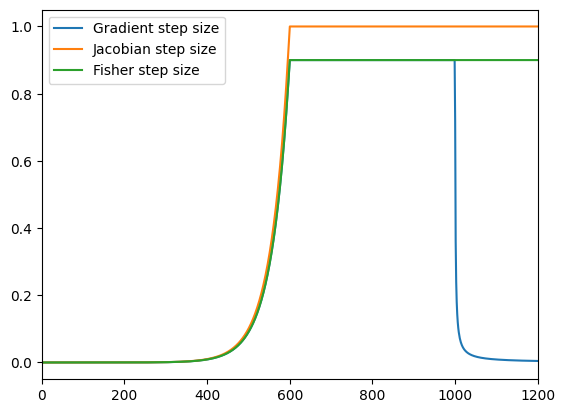

In [30]:
from sdg4varselect.outputs import MultiRunRes
from sdg4varselect.algo import SPGD_FIM, get_GDFIM_settings
from sdg4varselect.learning_rate import create_multi_step_size

algo_settings = get_GDFIM_settings(preheating=600, heating=1000, learning_rate=1e-6)
step_sizes = create_multi_step_size(list(algo_settings))
labels = ["Gradient step size", "Jacobian step size", "Fisher step size"]
[lr.plot(label=labels[i]) for i, lr in enumerate(step_sizes)]
sdgplt.plt.legend()
_ = sdgplt.plt.xlim(0, 1200)

We define a function that make one estimation run. we set $\varphi_1$ and $\varphi_2$ as latente variable, and use a MCMC-procedure in the algorithm to treat them :

In [31]:
from datetime import datetime


def one_estim(prngkey, model, data, lbd=None, save_all=True):
    prngkey_theta, prngkey_estim = jrd.split(prngkey)
    theta0 = 0.2 * jrd.normal(prngkey_theta, shape=(model.parametrization.size,))

    algo = SPGD_FIM(prngkey_estim, 10000, algo_settings, lbd=lbd, alpha=1.0)
    # =================== MCMC configuration ==================== #
    algo.init_mcmc(theta0, model, sd={"ksi": 20})

    algo.latent_variables["ksi"].adaptative_sd = True
    # ==================== END configuration ==================== #

    res = algo.fit(model, data, theta0, ntry=5, partial_fit=False, save_all=save_all)

    return res

Now we perform severals estimations : 

In [32]:
chrono_start = datetime.now()
# multi_res = MultiRunRes(
#     [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(20)]
# )
if "multi_res" not in locals():
    multi_res = MultiRunRes.load(myModel)
print(f"\ntotal = {datetime.now() - chrono_start} ")


total = 0:00:00.001754 


We can obtain the calculation time

In [33]:
print(f"\nComputation time = {multi_res.chrono}")


Computation time = 0:06:58.364146


And plot the results

1.8245574525419728


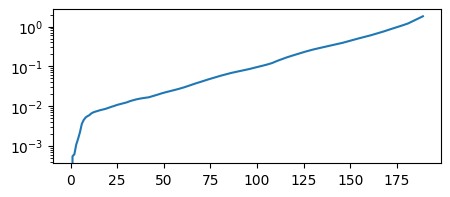

In [34]:
def cumvar(x):
    cumulative_mean = jnp.cumsum(x) / jnp.arange(1, len(x) + 1)
    return jnp.cumsum((x - cumulative_mean) ** 2) / jnp.arange(1, len(x) + 1)


multi_estim = multi_res.reduce_number_run(keep_percentage=0.95)
multi_estim.sort()
print(multi_estim.likelihood.var())

ax = sdgplt.get_ax(2, 5)
ax.plot(cumvar(multi_estim.likelihood))
ax.set_yscale("log")

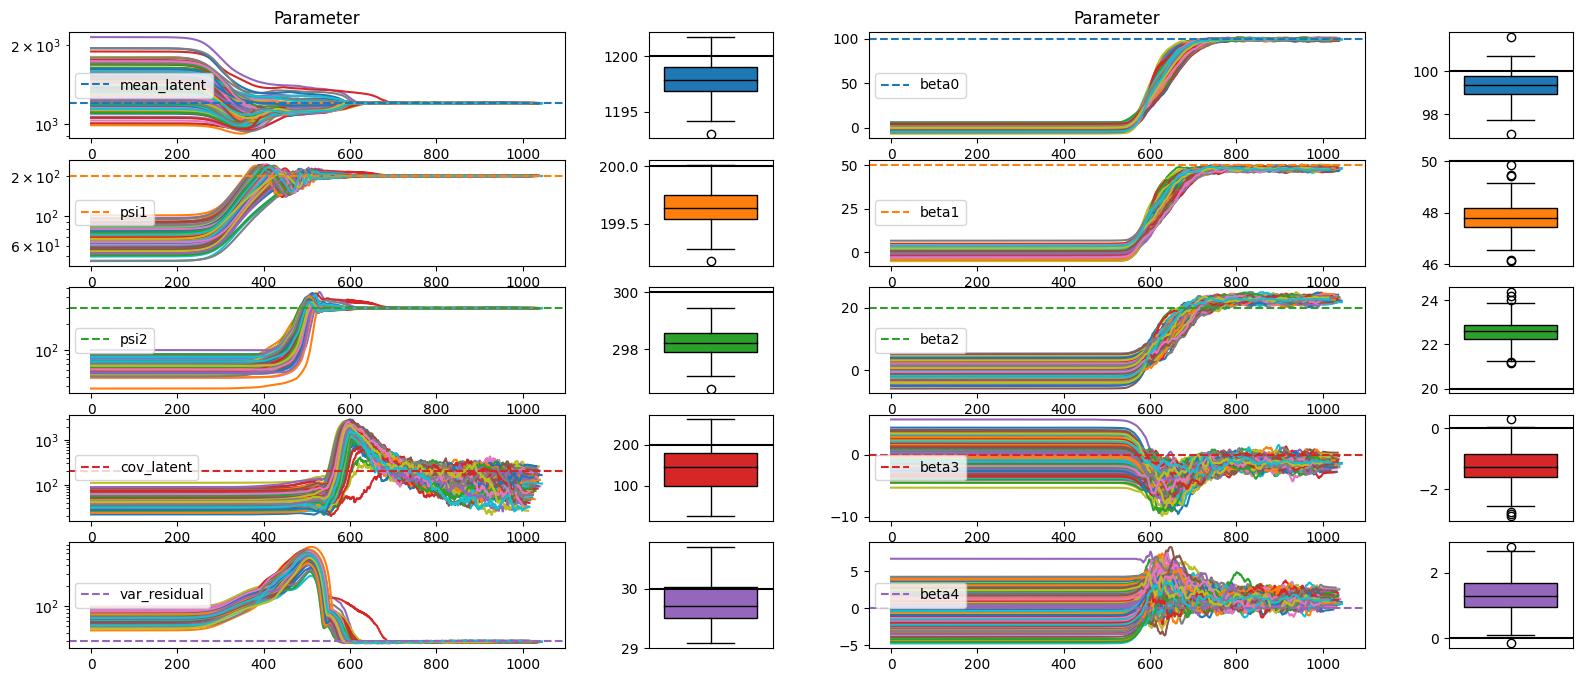

In [35]:
fig = sdgplt.figure(8, 16)
subfigs = fig.subfigures(1, 4, wspace=0.07, width_ratios=[4, 1, 4, 1])
id_to_plot = [i for i in range(myModel.DIM_LD)]

_ = sdgplt.plot_theta(
    multi_estim,
    dim_ld=myModel.DIM_LD,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
    id_to_plot=id_to_plot,
    log_scale=True,
    fig=subfigs[0],
)
f = sdgplt.boxplot_estimation(
    # multi_estim.last_theta.T,
    x=multi_estim.last_theta.T[id_to_plot,],
    hline=myModel.hstack_params(p_star)[id_to_plot,],
    # xlabels=myModel.params_names,
    nrows=len(id_to_plot),
    ncols=1,
    fig=subfigs[1],
)

for ax in f.axes:
    ax.set_xlim(1 + 0.1 * jnp.array([-1, 1]))
    ax.get_yaxis().get_major_formatter().set_useOffset(False)
    ax.ticklabel_format(style="plain", axis="y")

_ = sdgplt.plot_theta_hd(
    multi_estim,
    dim_ld=myModel.DIM_LD,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
    fig=subfigs[2],
)

f = sdgplt.boxplot_estimation(
    multi_estim.last_theta.T[myModel.DIM_LD :],
    hline=myModel.hstack_params(p_star)[myModel.DIM_LD :],
    # xlabels=myModel.params_names[myModel.DIM_LD :],
    nrows=5,
    ncols=1,
    fig=subfigs[3],
)
for ax in f.axes:
    ax.set_xlim(1 + 0.1 * jnp.array([-1, 1]))

# fig.tight_layout()

In [36]:
sdgplt.get_dataframe_results(
    multi_estim.last_theta, myModel.hstack_params(p_star), myModel.params_names
).style.format(
    {
        "real value": "{:.1f}".format,
        "mean": "{:.2f}".format,
        "variance": "{:.3f}".format,
        "rmse": "{:.4f}".format,
        "rrmse": "{:.1%}".format,
    }
)

,real value,mean,variance,rmse,rrmse
mean_latent,1200.0,1197.86,2.408,2.6438,0.2%
psi1,200.0,199.64,0.022,0.3918,0.2%
psi2,300.0,298.22,0.241,1.8479,0.6%
cov_latent,200.0,140.65,2735.780,79.1084,39.6%
var_residual,30.0,29.77,0.117,0.4131,1.4%
beta0,100.0,99.34,0.388,0.9089,0.9%
beta1,50.0,47.83,0.318,2.2437,4.5%
beta2,20.0,22.58,0.296,2.6387,13.2%
beta3,0.0,-1.25,0.306,1.3648,inf%
beta4,0.0,1.32,0.303,1.4279,inf%


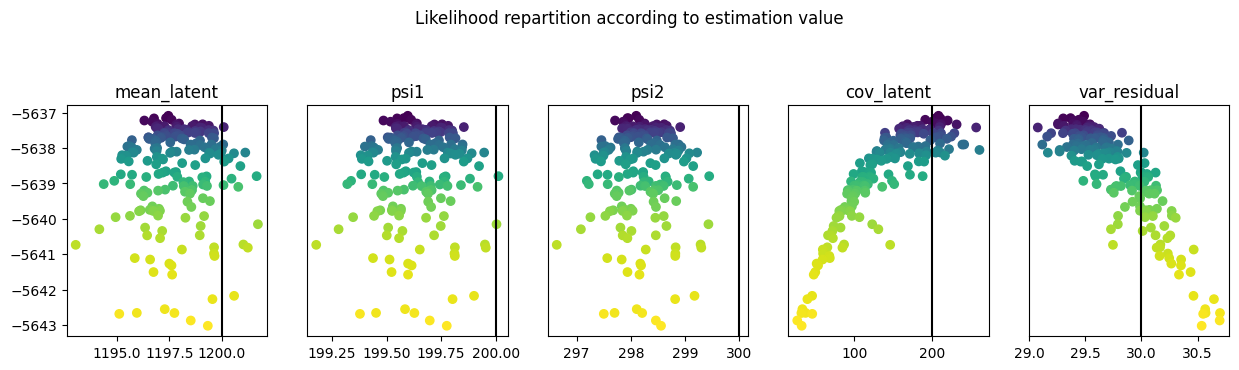

In [37]:
fig = sdgplt.scatter_estimation(
    multi_estim.last_theta[:, : myModel.DIM_LD].T,
    multi_estim.likelihood[:],
    vline=myModel.hstack_params(p_star)[: myModel.DIM_LD],
    labels=myModel.params_names[: myModel.DIM_LD],
    nrows=1,
    ncols=5,
    fig=sdgplt.figure(height=3, width=15),
)

_ = fig.suptitle("Likelihood repartition according to estimation value", y=1.2)

High Dimension

In [38]:
from sdg4varselect import regularization_path, lasso_into_estim
from sdg4varselect.outputs import RegularizationPathRes, MultiRunRes


def estim_with_flag(model, **kwargs) -> tuple[MultiRunRes, bool]:
    """must return the estimation results and
    a flag which indicates if the regularization path is finished"""
    res_estim = lasso_into_estim(one_estim, model=model, **kwargs)
    dim_ld = model.DIM_LD
    flag = (res_estim[-1].last_theta[dim_ld:] != 0).sum() == 0

    return res_estim, flag


def one_result(prngkey, model, data, lbd_set, save_all=True):

    list_sdg_results, bic = regularization_path(
        estim_fct_with_flag=estim_with_flag,
        prngkey=prngkey,
        lbd_set=lbd_set,
        dim_ld=model.DIM_LD,
        N=model.N * (1 + model.J),
        verbatim=True,  # __name__ == "__main__",
        # additional parameter
        model=model,
        data=data,
        save_all=save_all,
    )

    argmin_bic = bic[-1].argmin()

    return RegularizationPathRes(
        multi_run=list_sdg_results,
        argmin_bic=argmin_bic,
        bic=bic,
        lbd_set=lbd_set,
    )

One function for multiple estimation

In [39]:
from datetime import datetime

from sdg4varselect.exceptions import sdg4vsNanError
from sdg4varselect.outputs import MultiRunRes
from sdg4varselect.miscellaneous import step_message


# ====================================================== #
def multi_run(prngkey, lbd_set, params_star, model, nrun, save_all=True):
    chrono_start = datetime.now()
    print(f'start at {chrono_start.strftime("%d/%m/%Y %H:%M:%S")}')

    prngkey_list = jrd.split(prngkey, num=nrun)

    estim_res = []
    censoring_rate = []
    end = "\r" if __name__ == "__main__" else "\n"
    for k in range(nrun):
        print("run", step_message(k, nrun), end=end)
        data, _ = model.sample(params_star, prngkey_list[k])

        try:
            estim_res.append(
                one_result(
                    prngkey_list[k],
                    model,
                    data=data,
                    lbd_set=lbd_set,
                    save_all=save_all,
                ),
            )

        except sdg4vsNanError as err:
            print(f"{err} :  estimation cancelled !")

    return MultiRunRes(estim_res)

In [40]:
myHDModel = HDLogisticMixedEffectsModel(N=1000, J=10, P=1000)

p_star_hd = myHDModel.new_params(
    mean_latent={"mu": 1200},
    psi1=200,
    psi2=300,
    cov_latent=jnp.diag(jnp.array([200])),
    var_residual=30,
    beta=jnp.concatenate(
        [jnp.array([100, 50, 20]), jnp.zeros(shape=(myHDModel.P - 3,))]
    ),
)

lbd_set = 10 ** jnp.linspace(-1.5, -1, num=10)

In [41]:
# Run thos on a cluster
# res = multi_run(
#     jrd.PRNGKey(10),
#     lbd_set,
#     p_star_hd,
#     myHDModel,
#     nrun=1,
#     save_all=True,
# )

In [42]:
from sdg4varselect.outputs import TestResults

if "res" in locals():
    results = TestResults(
        [locals()["res"]],
        [{"N": myHDModel.N, "J": myHDModel.J, "P": myHDModel.P}],
    )
else:
    results = TestResults(
        [
            TestResults.load(HDLogisticMEM(1000, 10, 10), filename_add_on=f"S(1, 10)"),
            TestResults.load(HDLogisticMEM(1000, 10, 50), filename_add_on=f"S(22, 30)"),
            TestResults.load(HDLogisticMEM(200, 10, 50), filename_add_on=f"S(1, 10)"),
            TestResults.load(HDLogisticMEM(200, 10, 500), filename_add_on=f"S(1, 10)"),
            TestResults.load(HDLogisticMEM(200, 10, 1000), filename_add_on=f"S(1, 60)"),
        ],
        [
            {"N": 1000, "J": 10, "P": 10},
            {"N": 1000, "J": 10, "P": 50},
            {"N": 200, "J": 10, "P": 50},
            {"N": 200, "J": 10, "P": 500},
            {"N": 200, "J": 10, "P": 1000},
        ],
    )
    nrun_to_keep = min([len(t) for t in results])
    results = TestResults(
        [t.reduce_number_run(nrun_to_keep) for t in results], results.config
    )

print(f"chrono = {[str(t.chrono) for t in results]}")
print([len(t) for t in results])

import pandas as pd

pd.DataFrame(
    [
        [str(t.chrono / t.total_number_res) for t in results],
        [str(t.chrono / len(t[0])) for t in results],
    ],
    index=[
        "by fit",
        f"by estimation ( {results[0].total_number_res/len(results[0])} fits)",
    ],
    columns=[f'N = {c["N"]}, P = {c["P"]}' for c in results.config],
).T

HDLogisticMEM_N1000_J10_P10_S(1, 10) LOADED !
HDLogisticMEM_N1000_J10_P50_S(22, 30) LOADED !
HDLogisticMEM_N200_J10_P50_S(1, 10) LOADED !
HDLogisticMEM_N200_J10_P500_S(1, 10) LOADED !
HDLogisticMEM_N200_J10_P1000_S(1, 60) LOADED !
chrono = ['0:41:33.051790', '0:50:41.783280', '0:29:55.362547', '21 days, 1:41:08.559289', '10 days, 15:23:04.894639']
[45, 45, 45, 45, 45]


,by fit,by estimation ( 20.0 fits)
"N = 1000, P = 10",0:00:02.770058,0:04:09.305179
"N = 1000, P = 50",0:00:03.379759,0:05:04.178328
"N = 200, P = 50",0:00:01.994847,0:02:59.536255
"N = 200, P = 500",0:33:42.742844,"2 days, 2:34:06.855929"
"N = 200, P = 1000",0:17:01.538772,"1 day, 1:32:18.489464"


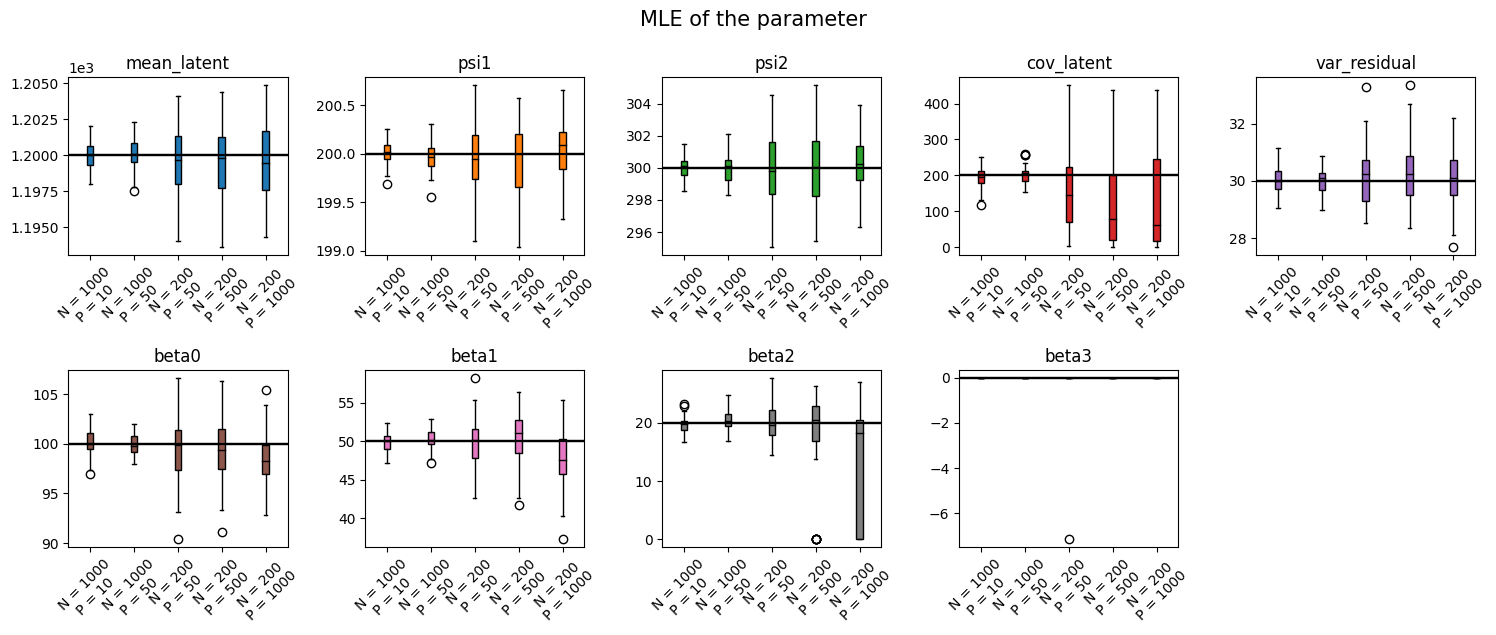

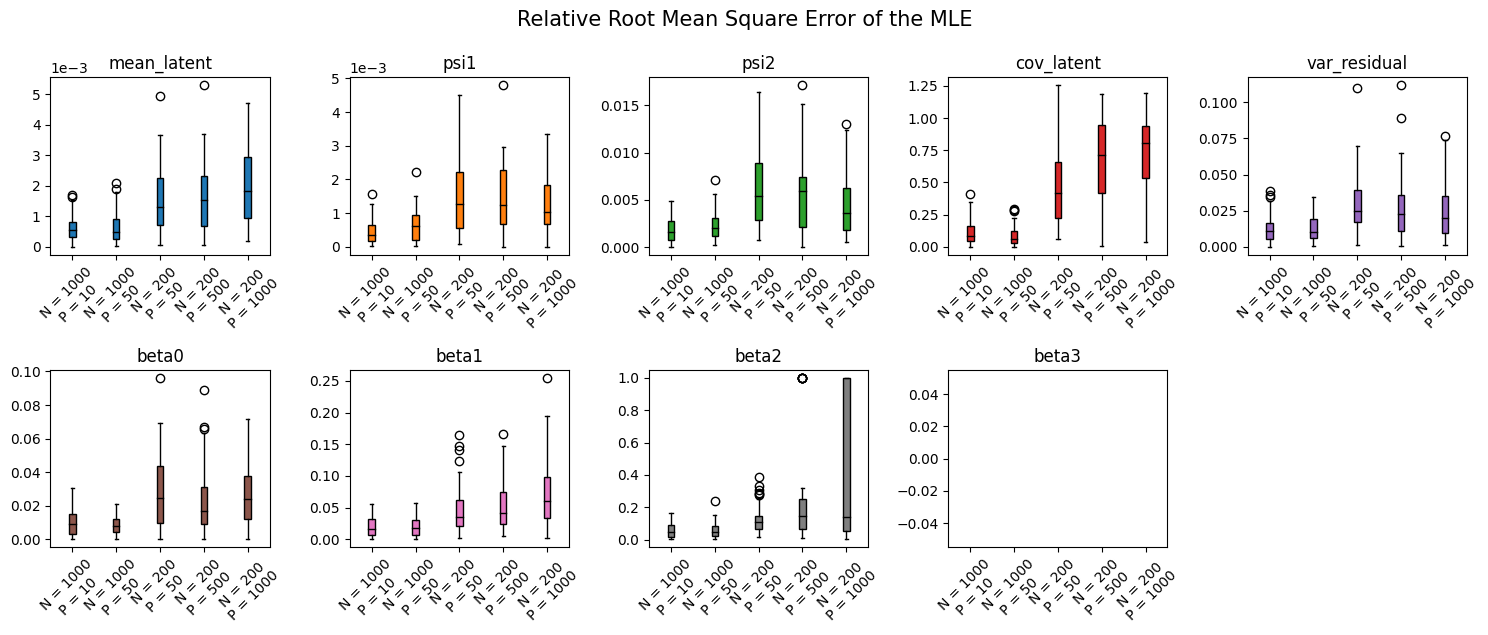

In [43]:
scenarios_labels = [
    f"{n}\n{p}"
    for n, p in zip(
        results.get_scenarios_labels("N"), results.get_scenarios_labels("P")
    )
]
x = results.last_theta[:, :, 1, : myModel.DIM_LD + 4]
fig = sdgplt.boxplot_estimation(
    x=x.T,
    hline=myHDModel.hstack_params(p_star_hd)[: myModel.DIM_LD + 4],
    xlabels=scenarios_labels,
    title=myHDModel.params_names[: myModel.DIM_LD + 4],
    nrows=2,
    ncols=5,
    fig=sdgplt.figure(height=6, width=15),
)

for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
_ = fig.suptitle("MLE of the parameter", fontsize=15, y=1.05)

x = jnp.abs((1 - x / myHDModel.hstack_params(p_star_hd)[: myModel.DIM_LD + 4]))
fig = sdgplt.boxplot_estimation(
    x=x.T,
    xlabels=scenarios_labels,
    title=myHDModel.params_names[: myModel.DIM_LD + 4],
    nrows=2,
    ncols=5,
    fig=sdgplt.figure(height=6, width=15),
)

for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
_ = fig.suptitle("Relative Root Mean Square Error of the MLE", fontsize=15, y=1.05)

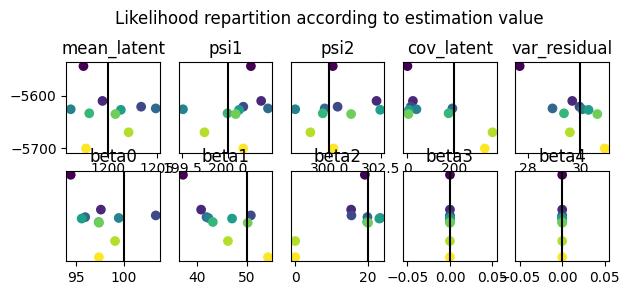

In [ ]:
fig = sdgplt.figure(height=4, width=7)
results[-1].sort()

_ = sdgplt.scatter_estimation(
    results[-1].last_theta[:, 1, : myModel.DIM_LD + 5 * 1].T,
    results[-1].likelihood[:, 1],
    vline=myHDModel.hstack_params(p_star)[: myModel.DIM_LD + 5 * 1],
    labels=myHDModel.params_names[: myModel.DIM_LD + 5 * 1],
    nrows=3,
    ncols=5,
    fig=fig,
)

_ = fig.suptitle("Likelihood repartition according to estimation value", y=1.01)

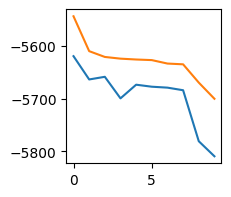

In [ ]:
sdgplt.get_ax(2, 2).plot(results[-1].likelihood)

In [ ]:
last_theta_estim = results[-1].last_theta[:, 1]

sdgplt.get_dataframe_results(
    last_theta_estim, myHDModel.hstack_params(p_star_hd), myHDModel.params_names
).style.format(
    {
        "real value": "{:.1f}".format,
        "mean": "{:.2f}".format,
        "variance": "{:.3f}".format,
        "rmse": "{:.4f}".format,
        "rrmse": "{:.1%}".format,
    }
)

,real value,mean,variance,rmse,rrmse
mean_latent,1200.0,1200.16,7.022,2.6548,0.2%
psi1,200.0,200.09,0.071,0.2804,0.1%
psi2,300.0,300.35,1.521,1.2814,0.4%
cov_latent,200.0,115.38,17652.829,157.5244,78.8%
var_residual,30.0,29.73,0.772,0.9203,3.1%
beta0,100.0,97.77,5.631,3.2559,3.3%
beta1,50.0,45.38,24.297,6.7590,13.5%
beta2,20.0,15.55,66.645,9.2954,46.5%
beta20,0.0,0.93,7.853,2.9539,inf%
beta33,0.0,-0.79,5.620,2.4989,inf%


In [86]:
from sdg4varselect._regularization_function import BIC, eBIC
reg = results[-1][0]
likelihood = [r.likelihood[-1] for r in reg]

bic = reg.bic

)

In [92]:
subfigs[0][0].axes

[<AxesSubplot: title={'center': 'Regularization path'}, xlabel='Regularization penalty ($\\lambda$)', ylabel='HD Parameter ($\\beta$)'>,
 <AxesSubplot: ylabel='BIC Score'>,
 <AxesSubplot: >]

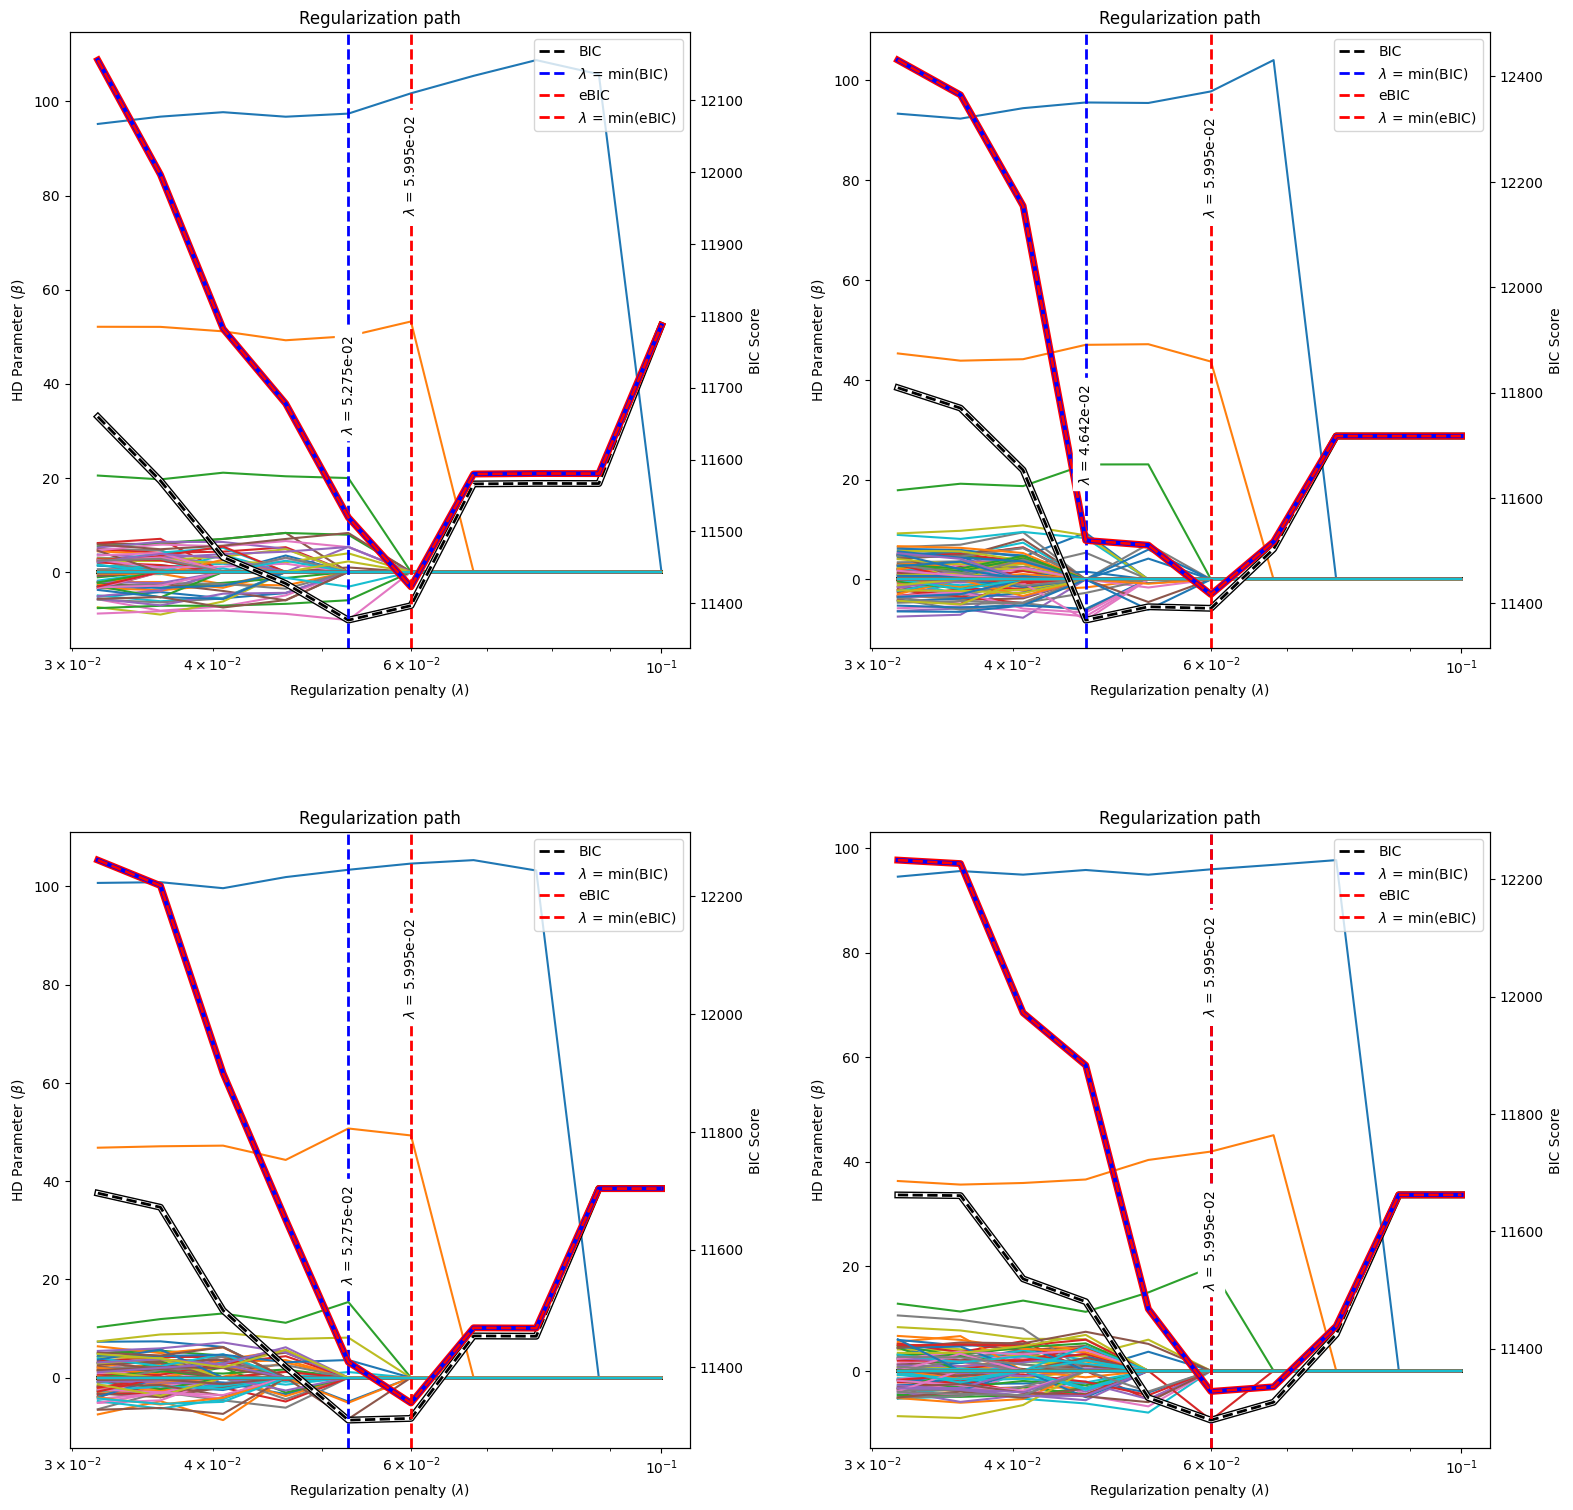

In [113]:
fig = sdgplt.figure(16, 16)
subfigs = fig.subfigures(2, 2, wspace=0.07)

for i, subfigsarr in enumerate(subfigs):
    for j, subfig in enumerate(subfigsarr):
        reg = results[-1][5 + i * subfigs.shape[0] + j]

        x = jnp.array([r.last_theta[-1, myHDModel.DIM_LD :] for r in reg])
        t = jnp.array([xx[~jnp.isnan(xx)] for xx in x])

        ebic = eBIC(
            t,
            jnp.array([r.likelihood[-1] for r in reg]),
            myModel.N * (1 + myModel.J),
        )

        fig = sdgplt.plot_reg_path(
            reg_res=reg,
            dim_ld=myHDModel.DIM_LD,
            fig=subfigs[i][j],
        )

        ax = fig.axes[1]
        ax.plot(reg.lbd_set, ebic, color="r", linewidth=5, linestyle="-")
        ax.plot(reg.lbd_set, ebic, color="b", linewidth=3, linestyle="-")
        ax.plot(reg.lbd_set, ebic, color="r", linewidth=2, linestyle="--", label="eBIC")

        sdgplt.plot_axvline(
            ax, lbd_set, ebic, i=jnp.argmin(ebic), color="r", msg=" = min(eBIC)"
        )

        ax.legend()

In [ ]:
x = results.last_theta[:, :, -1, myHDModel.DIM_LD :]
print(jnp.isnan(x))
print(x.shape)

print(jnp.repeat(x.shape[-2], x.shape[0]))

y = jnp.tile(p_star_hd.beta, reps=30)
print(y.shape)

jnp.tile(p_star_hd.beta, reps=x.shape[:-1] + (1,)).shape

[[[False False False ...  True  True  True]
  [False False False ...  True  True  True]
  [False False False ...  True  True  True]
  ...
  [False False False ...  True  True  True]
  [False False False ...  True  True  True]
  [False False False ...  True  True  True]]

 [[False False False ...  True  True  True]
  [False False False ...  True  True  True]
  [False False False ...  True  True  True]
  ...
  [False False False ...  True  True  True]
  [False False False ...  True  True  True]
  [False False False ...  True  True  True]]

 [[False False False ...  True  True  True]
  [False False False ...  True  True  True]
  [False False False ...  True  True  True]
  ...
  [False False False ...  True  True  True]
  [False False False ...  True  True  True]
  [False False False ...  True  True  True]]

 [[False False False ...  True  True  True]
  [False False False ...  True  True  True]
  [False False False ...  True  True  True]
  ...
  [False False False ...  True  True  True]
  

(5, 10, 1000)

In [ ]:
def get_support_star(x, x_star):
    xx_star = jnp.tile(p_star_hd.beta, reps=x.shape[:-1] + (1,))
    return jnp.where(jnp.isnan(x), jnp.nan, xx_star != 0)


support_star = get_support_star(
    results.last_theta[:, :, -1, myHDModel.DIM_LD :], p_star_hd.beta
)
print(support_star.shape)


def get_support(x, x_star):
    if len(x.shape) > 1:
        return jnp.array([get_support(xx, x_star) for xx in x])

    return jnp.where(jnp.isnan(x), jnp.nan, x != 0)


multi_support = get_support(
    results.last_theta[:, :, -1, myHDModel.DIM_LD :], p_star_hd.beta
)
print(multi_support.shape)

(5, 10, 1000)
(5, 10, 1000)


In [ ]:
jnp.nansum(multi_support, axis=-1)

Array([[ 3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.],
       [ 3.,  3.,  3.,  3.,  3.,  3.,  4.,  3.,  3.,  3.],
       [ 3.,  3.,  3.,  6.,  3.,  4.,  3.,  3.,  3.,  4.],
       [ 6., 12.,  3.,  9.,  3.,  5.,  7.,  2.,  4.,  2.],
       [19., 14.,  9.,  4., 10., 15.,  9., 14.,  3.,  2.]], dtype=float64)

In [ ]:
lbd_set

Array([0.03162278, 0.03593814, 0.04084239, 0.04641589, 0.05274997,
       0.05994843, 0.06812921, 0.07742637, 0.08799225, 0.1       ],      dtype=float64)

(array([[10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 9.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 7.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 4.,  2.,  2.,  0.,  1.,  1.,  0.,  0.,  0.,  0.],
        [ 2.,  1.,  0.,  0.,  3.,  0.,  0.,  3.,  0.,  1.]]),
 array([ 2. ,  3.7,  5.4,  7.1,  8.8, 10.5, 12.2, 13.9, 15.6, 17.3, 19. ]),
 <a list of 5 BarContainer objects>)

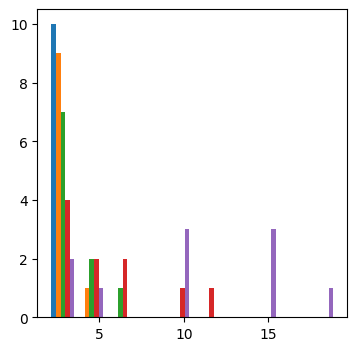

In [ ]:
ax = sdgplt.get_ax(4, 4)

ax.hist(jnp.nansum(multi_support, axis=-1))

[[1.         0.        ]
 [0.90000004 0.1       ]
 [0.7        0.3       ]
 [0.2        0.6       ]
 [0.         0.8       ]]


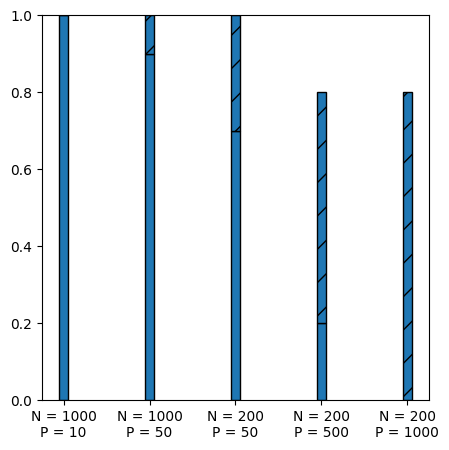

In [ ]:
all_component = jnp.nansum(jnp.abs(multi_support - support_star), axis=-1) == 0
first_component = (multi_support == support_star)[:, :, :3].mean(axis=-1) == 1
overselection = jnp.logical_and(first_component, jnp.logical_not(all_component))

score_support = jnp.array([all_component, overselection]).mean(axis=-1).T
print(score_support)

labels = ["Exact", "Over-selection"]
hatchs = ["", "/"]

ax = sdgplt.get_ax(5, 5)
for i in range(score_support.shape[0]):
    for j in range(len(labels)):
        ax.bar(
            scenarios_labels[i],
            score_support[i, j],
            label=labels[j],
            bottom=score_support[i, :j].sum(axis=0),
            color=f"C{0}",
            edgecolor="black",
            width=0.1,
            hatch=hatchs[j],
        )